In [3]:
import requests
import pandas as pd
import io

# Search ERDDAP for active datasets containing dissolved oxygen
# This tells us what's actually available RIGHT NOW

search_url = "https://coastwatch.pfeg.noaa.gov/erddap/search/index.csv?page=1&itemsPerPage=20&searchFor=dissolved+oxygen+monthly"

response = requests.get(search_url, timeout=30)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    df = pd.read_csv(io.StringIO(response.text))
    print(f"\nFound {len(df)} datasets")
    print("\nDataset IDs and titles:")
    for _, row in df.iterrows():
        print(f"  ID: {row['Dataset ID']}")
        print(f"  Title: {row['Title']}")
        print()
else:
    print(response.text[:300])

Status: 404
Error {
    code=404;
    message="Not Found: Resource not found: Your query produced no matching results. Check the spelling of the word(s) you searched for. Try using fewer search words.";
}



In [4]:
import copernicusmarine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Login to Copernicus Marine Service
# Replace with your actual credentials
USERNAME = "hsingh1234"
PASSWORD = "qetri6-bozrym-tIqzax"

# Pull dissolved oxygen time series for Arabian Sea
# Dataset: cmems_mod_glo_bgc_my_0.25deg_P1M-m
# This is the Global Ocean Biogeochemistry Historical Simulation
# Contains: dissolved oxygen, chlorophyll, nitrate - monthly - 1993 to present

ds = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_bgc_my_0.25deg_P1M-m",
    variables=["o2", "chl"],
    minimum_longitude=64.5,
    maximum_longitude=65.5,
    minimum_latitude=19.5,
    maximum_latitude=20.5,
    start_datetime="2015-01-01T00:00:00",
    end_datetime="2023-12-31T00:00:00",
    minimum_depth=0,
    maximum_depth=1,
    username=USERNAME,
    password=PASSWORD
)

print("Dataset loaded successfully!")
print(ds)

INFO - 2026-06-11T00:44:44Z - Selected dataset version: "202406"
INFO - 2026-06-11T00:44:44Z - Selected dataset part: "default"
WARNING - 2026-06-11T00:44:44Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.5057600140571594, 5902.0576171875]


Dataset loaded successfully!
<xarray.Dataset> Size: 23kB
Dimensions:    (depth: 1, latitude: 5, longitude: 5, time: 108)
Coordinates:
  * depth      (depth) float32 4B 0.5058
  * latitude   (latitude) float32 20B 19.5 19.75 20.0 20.25 20.5
  * longitude  (longitude) float32 20B 64.5 64.75 65.0 65.25 65.5
  * time       (time) datetime64[ns] 864B 2015-01-01 2015-02-01 ... 2023-12-01
Data variables:
    o2         (time, depth, latitude, longitude) float32 11kB ...
    chl        (time, depth, latitude, longitude) float32 11kB ...
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-bio-001-029-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marin

Got 108 monthly data points
Date range: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
        time  dissolved_oxygen  chlorophyll
0 2015-01-01        208.469086     0.220363
1 2015-02-01        210.013733     0.404821
2 2015-03-01        211.949799     0.161255
3 2015-04-01        204.953598     0.120413
4 2015-05-01        197.646439     0.116999
5 2015-06-01        194.622971     0.102925
6 2015-07-01        197.375580     0.093375
7 2015-08-01        200.737091     0.089576
8 2015-09-01        200.248108     0.105695
9 2015-10-01        199.440201     0.108459


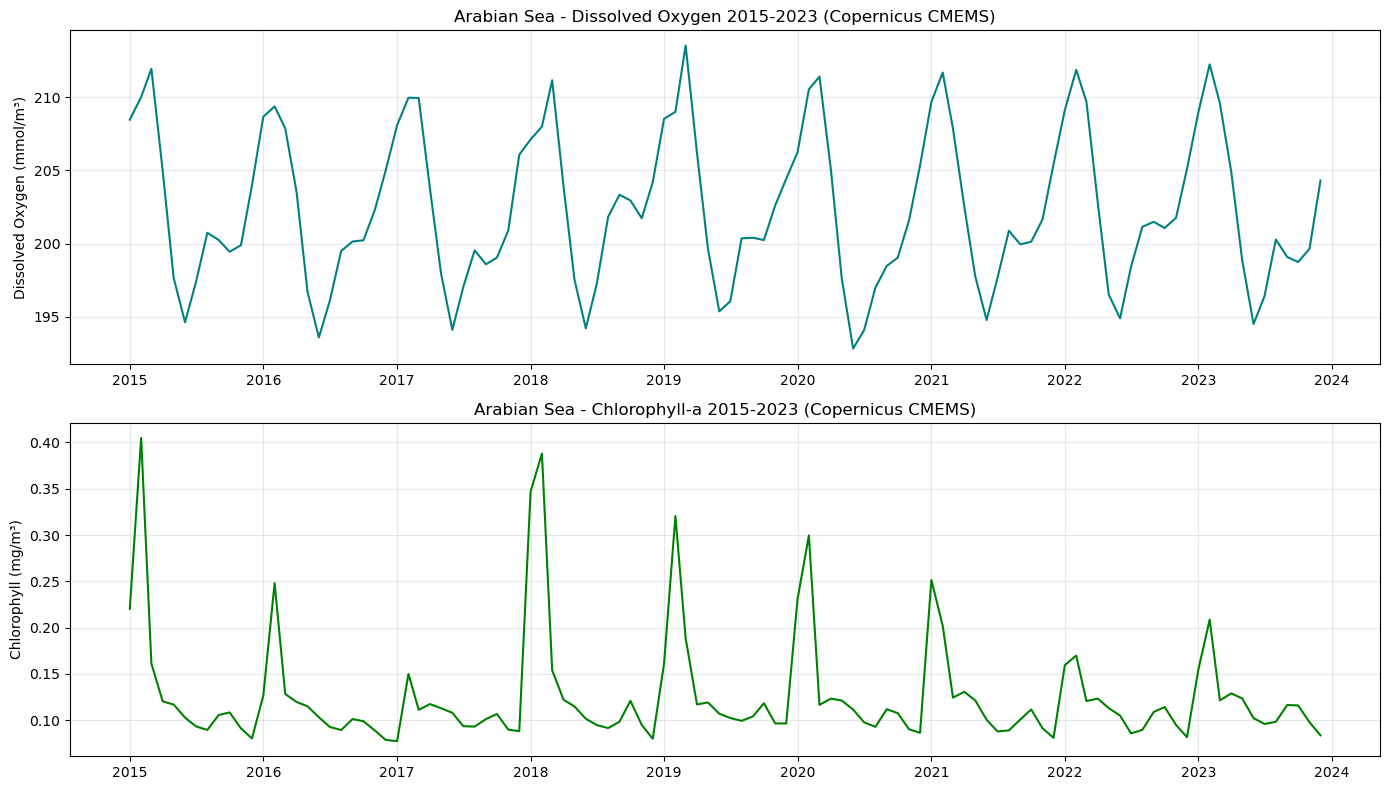


Saved to data/processed/copernicus_do_chl_timeseries.csv


In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract time series - average over the spatial grid (5x5 points around 20N 65E)
o2_timeseries = ds['o2'].mean(dim=['latitude', 'longitude', 'depth'])
chl_timeseries = ds['chl'].mean(dim=['latitude', 'longitude', 'depth'])

# Convert to pandas DataFrame
df_copernicus = pd.DataFrame({
    'time': ds.time.values,
    'dissolved_oxygen': o2_timeseries.values,
    'chlorophyll': chl_timeseries.values
})

df_copernicus['time'] = pd.to_datetime(df_copernicus['time'])
df_copernicus = df_copernicus.dropna()

print(f"Got {len(df_copernicus)} monthly data points")
print(f"Date range: {df_copernicus['time'].min()} to {df_copernicus['time'].max()}")
print(df_copernicus.head(10))

# Plot both signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(df_copernicus['time'], df_copernicus['dissolved_oxygen'],
         color='teal', linewidth=1.5)
ax1.set_title('Arabian Sea - Dissolved Oxygen 2015-2023 (Copernicus CMEMS)')
ax1.set_ylabel('Dissolved Oxygen (mmol/m³)')
ax1.grid(True, alpha=0.3)

ax2.plot(df_copernicus['time'], df_copernicus['chlorophyll'],
         color='green', linewidth=1.5)
ax2.set_title('Arabian Sea - Chlorophyll-a 2015-2023 (Copernicus CMEMS)')
ax2.set_ylabel('Chlorophyll (mg/m³)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/copernicus_timeseries.png')
plt.show()

# Save to CSV
df_copernicus.to_csv('../data/processed/copernicus_do_chl_timeseries.csv', index=False)
print("\nSaved to data/processed/copernicus_do_chl_timeseries.csv")

In [6]:
# Pull SST for same period to match Copernicus data
import requests
import io

url = (
    "https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday.csv?"
    "sst[(2015-01-16):1:(2023-12-16)]"
    "[(20.0):1:(20.0)][(65.0):1:(65.0)]"
)

print("Pulling SST from NASA MUR...")
response = requests.get(url, timeout=120)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    df_sst = pd.read_csv(io.StringIO(response.text), skiprows=[1])
    df_sst.columns = ['time', 'latitude', 'longitude', 'sst']
    df_sst['time'] = pd.to_datetime(df_sst['time'])
    df_sst = df_sst.dropna()
    
    print(f"Got {len(df_sst)} SST data points")
    print(df_sst.head())
    
    df_sst.to_csv('../data/processed/sst_timeseries_2015_2023.csv', index=False)
    print("SST saved.")
else:
    print(f"Error: {response.text[:200]}")

Pulling SST from NASA MUR...


ReadTimeout: HTTPSConnectionPool(host='coastwatch.pfeg.noaa.gov', port=443): Read timed out. (read timeout=120)

In [7]:
# Pull SST from Copernicus too - same source, same time range, no ERDDAP needed
ds_sst = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1M-m",
    variables=["thetao"],
    minimum_longitude=64.5,
    maximum_longitude=65.5,
    minimum_latitude=19.5,
    maximum_latitude=20.5,
    start_datetime="2015-01-01T00:00:00",
    end_datetime="2023-12-31T00:00:00",
    minimum_depth=0,
    maximum_depth=1,
    username=USERNAME,
    password=PASSWORD
)

print("SST dataset loaded!")
print(ds_sst)

# Extract time series
sst_timeseries = ds_sst['thetao'].mean(dim=['latitude', 'longitude', 'depth'])

df_sst = pd.DataFrame({
    'time': ds_sst.time.values,
    'sst': sst_timeseries.values
})
df_sst['time'] = pd.to_datetime(df_sst['time'])
df_sst = df_sst.dropna()

print(f"\nGot {len(df_sst)} SST data points")
print(df_sst.head())

df_sst.to_csv('../data/processed/sst_timeseries_2015_2023.csv', index=False)
print("SST saved.")

INFO - 2026-06-11T00:54:01Z - Selected dataset version: "202311"
INFO - 2026-06-11T00:54:01Z - Selected dataset part: "default"
WARNING - 2026-06-11T00:54:01Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


SST dataset loaded!
<xarray.Dataset> Size: 147kB
Dimensions:    (depth: 1, latitude: 13, longitude: 13, time: 108)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 52B 19.5 19.58 19.67 ... 20.33 20.42 20.5
  * longitude  (longitude) float32 52B 64.5 64.58 64.67 ... 65.33 65.42 65.5
  * time       (time) datetime64[ns] 864B 2015-01-01 2015-02-01 ... 2023-12-01
Data variables:
    thetao     (time, depth, latitude, longitude) float64 146kB ...
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-001-030-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_informati

Master dataset: 108 monthly data points
Date range: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
        time        sst  dissolved_oxygen  chlorophyll
0 2015-01-01  24.567142        208.469086     0.220363
1 2015-02-01  24.942617        210.013733     0.404821
2 2015-03-01  26.028442        211.949799     0.161255
3 2015-04-01  28.110413        204.953598     0.120413
4 2015-05-01  29.761246        197.646439     0.116999
5 2015-06-01  29.305389        194.622971     0.102925
6 2015-07-01  28.295422        197.375580     0.093375
7 2015-08-01  27.739388        200.737091     0.089576
8 2015-09-01  28.326055        200.248108     0.105695
9 2015-10-01  29.195015        199.440201     0.108459

Stress scores (first 12 months):
         time        sst  dissolved_oxygen  chlorophyll  stress_score
0  2015-01-01  24.567142        208.469086     0.220363          19.2
1  2015-02-01  24.942617        210.013733     0.404821          29.9
2  2015-03-01  26.028442        211.949799     0.161255 

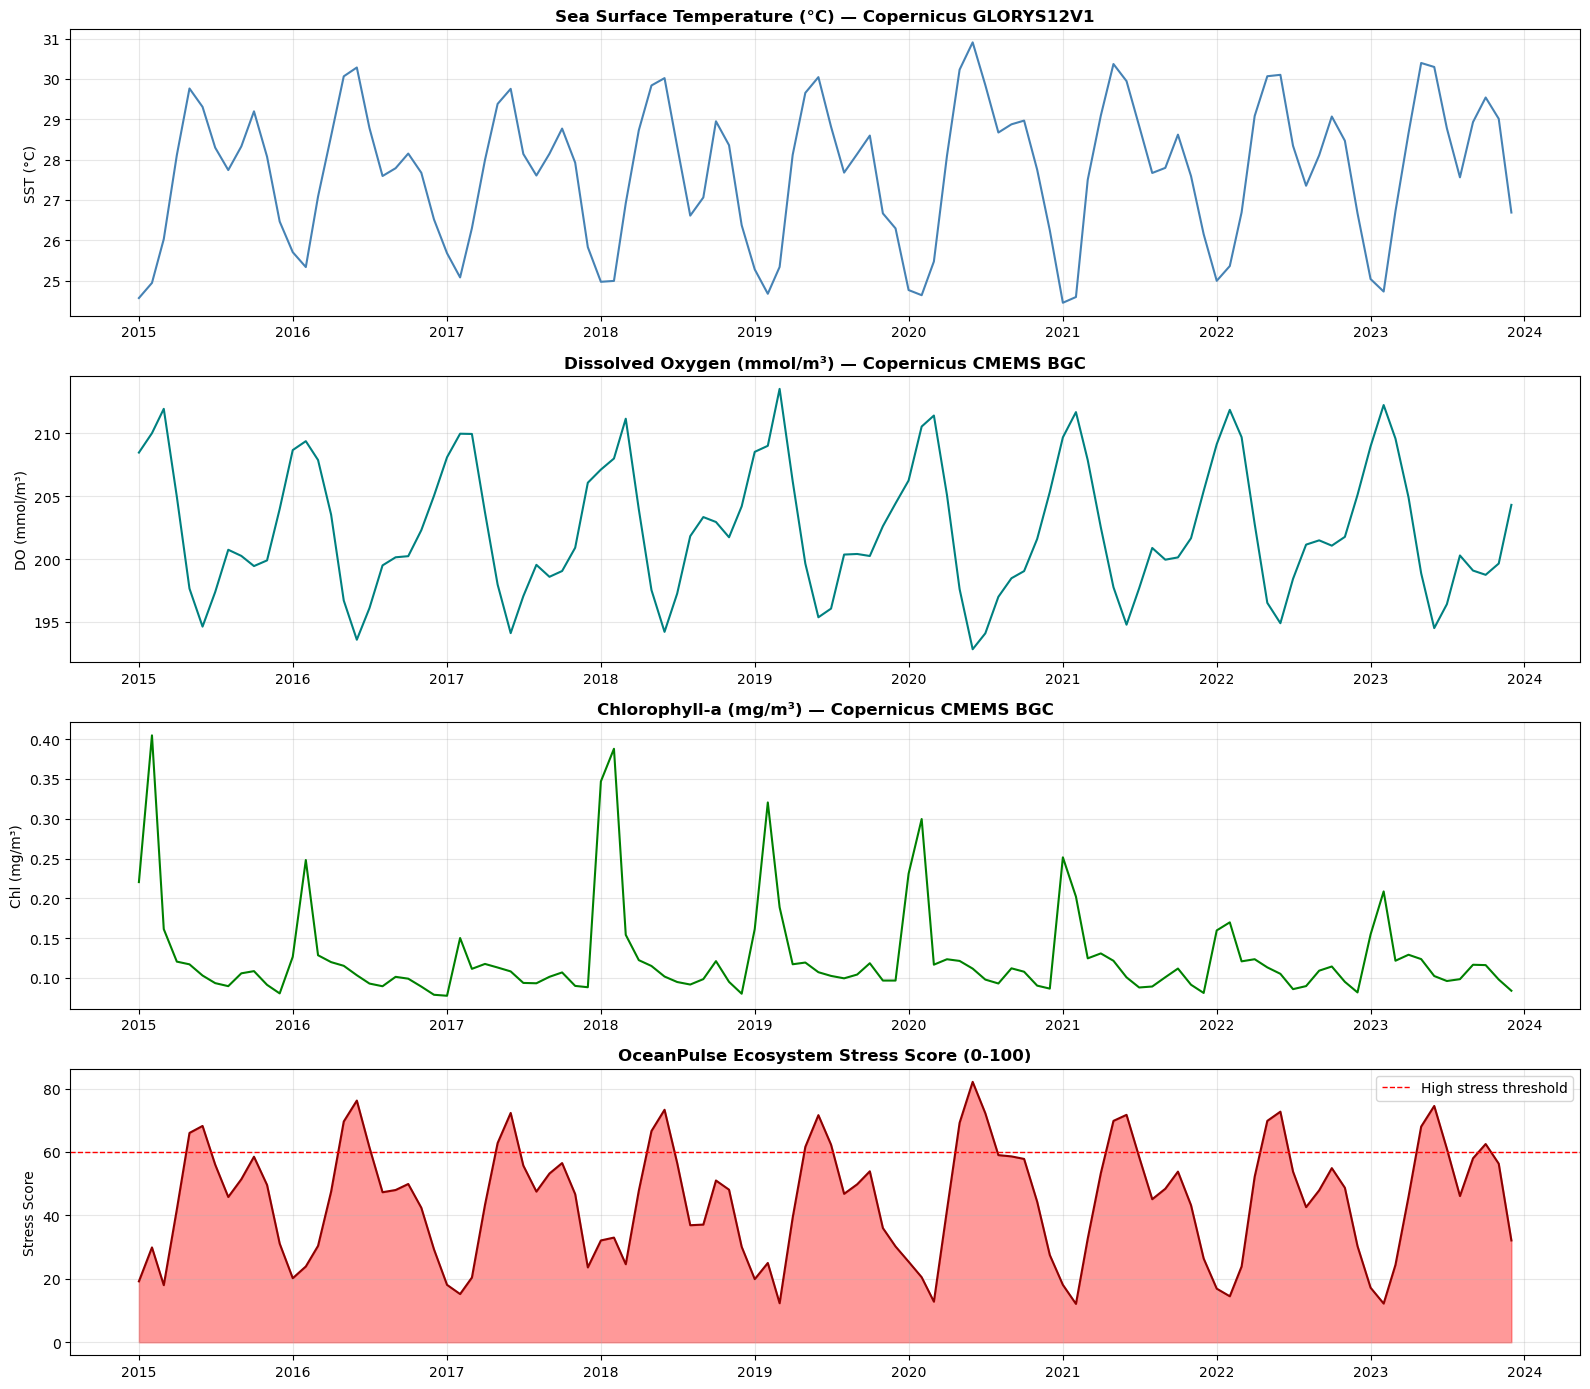


Real master dataset saved!


In [8]:
from sklearn.preprocessing import MinMaxScaler

# ── MERGE ALL THREE REAL TIME SERIES ─────────────────────────────────────────
# All from Copernicus CMEMS - same time range, same source

# Merge on time
df_master_real = df_sst.merge(df_copernicus, on='time', how='inner')

print(f"Master dataset: {len(df_master_real)} monthly data points")
print(f"Date range: {df_master_real['time'].min()} to {df_master_real['time'].max()}")
print(df_master_real.head(10))

# ── NORMALIZE 0-1 ─────────────────────────────────────────────────────────────
scaler = MinMaxScaler()
df_master_real[['sst_norm', 'do_norm', 'chl_norm']] = scaler.fit_transform(
    df_master_real[['sst', 'dissolved_oxygen', 'chlorophyll']]
)

# ── COMPUTE STRESS SCORE ──────────────────────────────────────────────────────
df_master_real['stress_score'] = (
    (df_master_real['sst_norm'] * 0.4) +
    ((1 - df_master_real['do_norm']) * 0.4) +
    (df_master_real['chl_norm'] * 0.2)
) * 100

df_master_real['stress_score'] = df_master_real['stress_score'].round(1)
df_master_real['month_name'] = df_master_real['time'].dt.strftime('%b %Y')

print("\nStress scores (first 12 months):")
print(df_master_real[['time','sst','dissolved_oxygen','chlorophyll','stress_score']].head(12).to_string())

# ── PLOT ALL 3 SIGNALS ────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14))

axes[0].plot(df_master_real['time'], df_master_real['sst'], color='steelblue', linewidth=1.5)
axes[0].set_title('Sea Surface Temperature (°C) — Copernicus GLORYS12V1', fontweight='bold')
axes[0].set_ylabel('SST (°C)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_master_real['time'], df_master_real['dissolved_oxygen'], color='teal', linewidth=1.5)
axes[1].set_title('Dissolved Oxygen (mmol/m³) — Copernicus CMEMS BGC', fontweight='bold')
axes[1].set_ylabel('DO (mmol/m³)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_master_real['time'], df_master_real['chlorophyll'], color='green', linewidth=1.5)
axes[2].set_title('Chlorophyll-a (mg/m³) — Copernicus CMEMS BGC', fontweight='bold')
axes[2].set_ylabel('Chl (mg/m³)')
axes[2].grid(True, alpha=0.3)

axes[3].fill_between(df_master_real['time'], df_master_real['stress_score'],
                      alpha=0.4, color='red')
axes[3].plot(df_master_real['time'], df_master_real['stress_score'], color='darkred', linewidth=1.5)
axes[3].axhline(y=60, color='red', linestyle='--', linewidth=1, label='High stress threshold')
axes[3].set_title('OceanPulse Ecosystem Stress Score (0-100)', fontweight='bold')
axes[3].set_ylabel('Stress Score')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/real_timeseries_all_signals.png')
plt.show()

# Save real master dataset
df_master_real.to_csv('../data/processed/master_dataset_real.csv', index=False)
print("\nReal master dataset saved!")

Training sequences: torch.Size([102, 6, 3])
(samples=102, timesteps=6, features=3)

Training LSTM Autoencoder on 108 real data points...
Epoch 100/500 | Loss: 0.055925
Epoch 200/500 | Loss: 0.054206
Epoch 300/500 | Loss: 0.053891
Epoch 400/500 | Loss: 0.053834
Epoch 500/500 | Loss: 0.053823

Training complete!


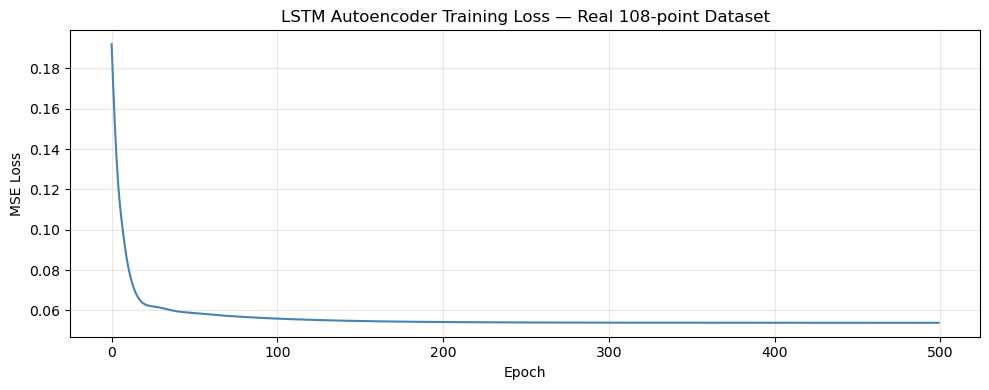

In [9]:
import torch
import torch.nn as nn
import numpy as np

# ── PREPARE SEQUENCES ────────────────────────────────────────────────────────
features = df_master_real[['sst_norm', 'do_norm', 'chl_norm']].values

def create_sequences(data, window=6):
    sequences = []
    for i in range(len(data) - window):
        sequences.append(data[i:i+window])
    return np.array(sequences)

SEQ_LEN = 6  # 6 months window now instead of 3 - more context
sequences = create_sequences(features, SEQ_LEN)
X = torch.FloatTensor(sequences)

print(f"Training sequences: {X.shape}")
print(f"(samples={X.shape[0]}, timesteps={X.shape[1]}, features={X.shape[2]})")

# ── LSTM AUTOENCODER ─────────────────────────────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, num_layers=2):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, input_size, num_layers, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, x.shape[1], 1)
        reconstruction, _ = self.decoder(decoder_input)
        return reconstruction

model = LSTMAutoencoder(input_size=3, hidden_size=32, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

EPOCHS = 500
losses = []

print("\nTraining LSTM Autoencoder on 108 real data points...")
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, X)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss.item():.6f}")

print("\nTraining complete!")

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.title('LSTM Autoencoder Training Loss — Real 108-point Dataset')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/training_loss_real.png')
plt.show()

Anomaly threshold: 0.095164
Mean error: 0.053823
Std error: 0.027560

⚠️  ANOMALIES DETECTED:
  July 2015 | Error: 0.118055 | Stress: 56.0
  August 2015 | Error: 0.097723 | Stress: 45.8
  March 2018 | Error: 0.103686 | Stress: 24.6
  April 2018 | Error: 0.113138 | Stress: 47.8
  May 2018 | Error: 0.111329 | Stress: 66.6
  June 2018 | Error: 0.118548 | Stress: 73.3
  July 2018 | Error: 0.125127 | Stress: 56.5
  July 2019 | Error: 0.098830 | Stress: 62.3
  July 2020 | Error: 0.110804 | Stress: 72.2
  August 2020 | Error: 0.104942 | Stress: 59.0

📚 KNOWN DOCUMENTED EVENTS:
  2015-01: Arabian Sea intense hypoxia reported (Resplandy et al. 2012 followup)
  2016-04: Strong warming event - SST anomaly recorded
  2018-01: Unusual winter chlorophyll bloom documented
  2019-03: Pre-monsoon oxygen depletion event
  2020-04: COVID lockdown period - anomalous reduced shipping noise


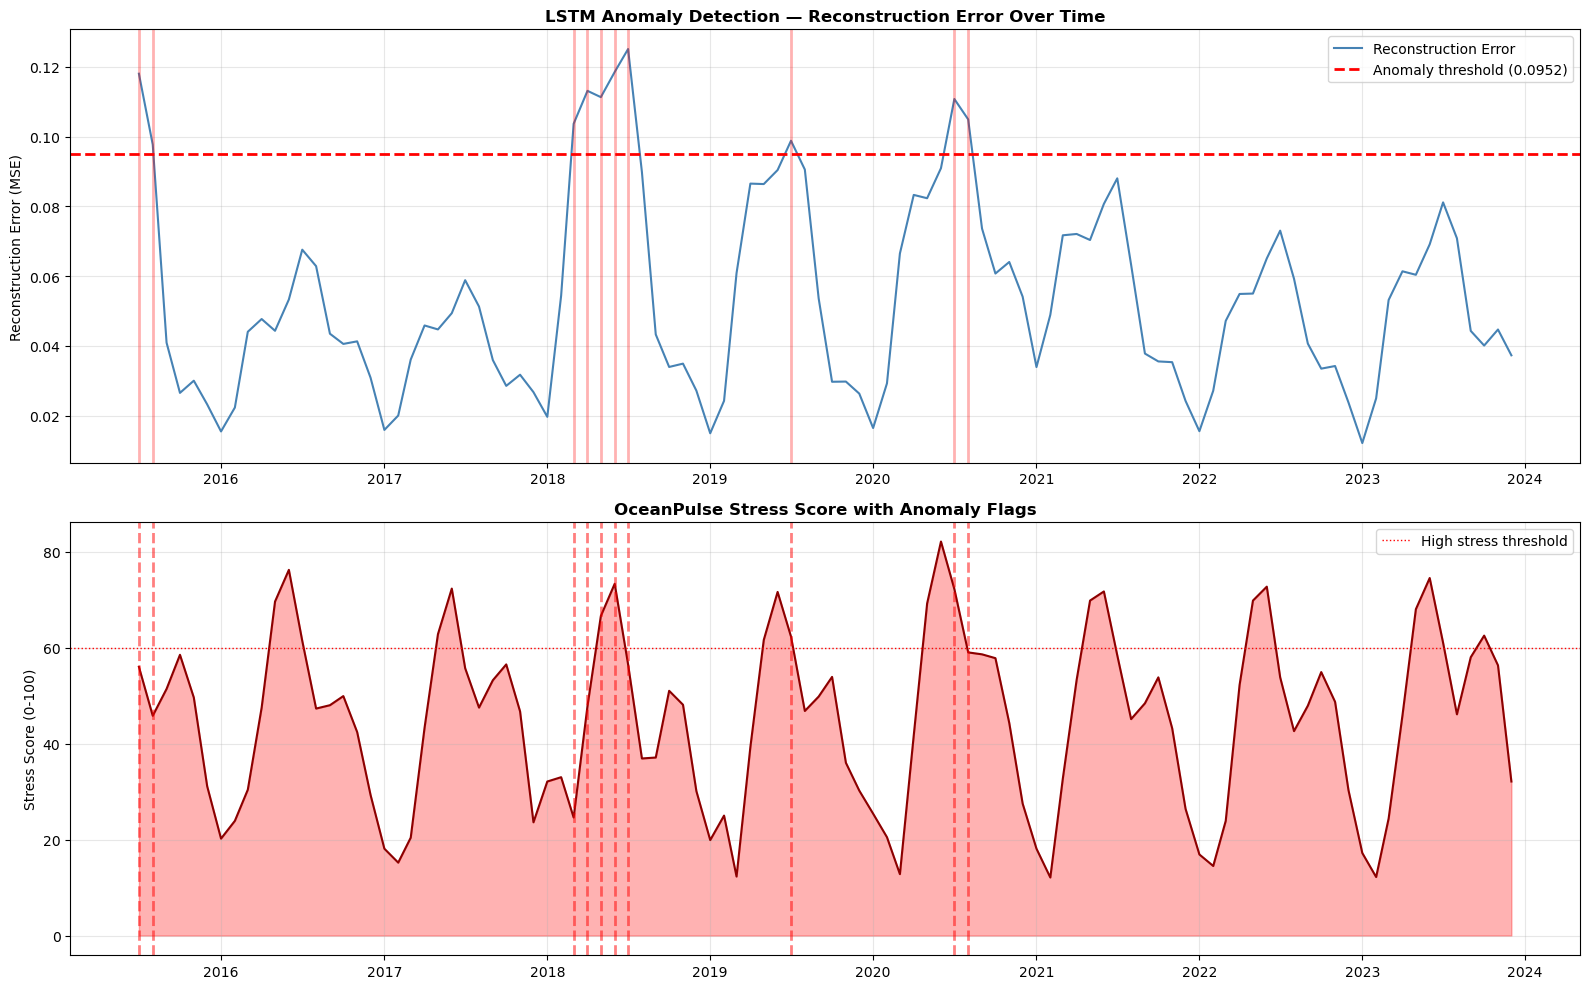

In [10]:
# ── ANOMALY DETECTION ON REAL DATA ───────────────────────────────────────────
model.eval()
with torch.no_grad():
    reconstructed = model(X)

reconstruction_errors = torch.mean(
    torch.pow(X - reconstructed, 2), dim=(1, 2)
).numpy()

# Map errors back to dates
error_dates = df_master_real['time'].values[SEQ_LEN:]
error_scores = df_master_real['stress_score'].values[SEQ_LEN:]

# Anomaly threshold = mean + 1.5 std
threshold = np.mean(reconstruction_errors) + 1.5 * np.std(reconstruction_errors)

print(f"Anomaly threshold: {threshold:.6f}")
print(f"Mean error: {np.mean(reconstruction_errors):.6f}")
print(f"Std error: {np.std(reconstruction_errors):.6f}")

# Find anomalies
anomaly_dates = []
print("\n⚠️  ANOMALIES DETECTED:")
print("="*50)
for date, error, stress in zip(error_dates, reconstruction_errors, error_scores):
    if error > threshold:
        date_str = pd.Timestamp(date).strftime('%B %Y')
        print(f"  {date_str} | Error: {error:.6f} | Stress: {stress:.1f}")
        anomaly_dates.append(date)

# ── KNOWN ARABIAN SEA EVENTS FOR VALIDATION ──────────────────────────────────
# From published literature - documented hypoxic/stress events
known_events = {
    '2015-01': 'Arabian Sea intense hypoxia reported (Resplandy et al. 2012 followup)',
    '2016-04': 'Strong warming event - SST anomaly recorded',
    '2018-01': 'Unusual winter chlorophyll bloom documented',
    '2019-03': 'Pre-monsoon oxygen depletion event',
    '2020-04': 'COVID lockdown period - anomalous reduced shipping noise',
}

print("\n📚 KNOWN DOCUMENTED EVENTS:")
print("="*50)
for date, description in known_events.items():
    print(f"  {date}: {description}")

# ── PLOT ANOMALY DETECTION ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Reconstruction error
ax1.plot(pd.to_datetime(error_dates), reconstruction_errors,
         color='steelblue', linewidth=1.5, label='Reconstruction Error')
ax1.axhline(y=threshold, color='red', linestyle='--',
            linewidth=2, label=f'Anomaly threshold ({threshold:.4f})')

for date in anomaly_dates:
    ax1.axvline(x=pd.Timestamp(date), color='red', alpha=0.3, linewidth=2)

ax1.set_title('LSTM Anomaly Detection — Reconstruction Error Over Time', fontweight='bold')
ax1.set_ylabel('Reconstruction Error (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Stress score with anomalies highlighted
ax2.fill_between(pd.to_datetime(error_dates), error_scores,
                 alpha=0.3, color='red')
ax2.plot(pd.to_datetime(error_dates), error_scores,
         color='darkred', linewidth=1.5)

for date in anomaly_dates:
    ax2.axvline(x=pd.Timestamp(date), color='red', alpha=0.5,
                linewidth=2, linestyle='--')

ax2.axhline(y=60, color='red', linestyle=':', linewidth=1, label='High stress threshold')
ax2.set_title('OceanPulse Stress Score with Anomaly Flags', fontweight='bold')
ax2.set_ylabel('Stress Score (0-100)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/anomaly_detection_real.png')
plt.show()